# Q3D Capacitance Matrix of a MultiPlanar Design with pyaedt

A `MultiPlanar` design reads its layers from a layer-stack file: for each layer, its z position, thickness, material and whether it is filled. The pyaedt renderers use that stack to build the 3D model in Ansys.

**Note:** this may work only with the full (paid) version of Ansys, not the student version. This issue is fixable and requires more testing. Please run the notebook and test it out on student license, if you're interested to make a contribution!

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qiskit-community/qiskit-metal/blob/main/docs/tut/4-Analysis/pyaedt-multiplanar/Q3D-pyaedt-multiplanar.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/qiskit-community/qiskit-metal/main?labpath=docs%2Ftut%2F4-Analysis%2Fpyaedt-multiplanar%2FQ3D-pyaedt-multiplanar.ipynb)

> 💡 **Desktop GUI or inline.** `metal.gui(design)` opens the desktop `MetalGUI` when Qt and a display are available and falls back to an inline viewer (Colab, Binder, a server) with the same API, so `gui.rebuild()` and `gui.screenshot()` work in both. See [1.1 Quick start](https://qiskit-community.github.io/qiskit-metal/tut/1-Overview/1.1-Quick-start.html) and [`docs/headless-usage.rst`](https://qiskit-community.github.io/qiskit-metal/headless-usage.html).
>
> Everything up to and including the layout runs anywhere. The rest drives Ansys through pyaedt (Q3D: setup, analysis, capacitance matrix per pass); those cells need Ansys Electronics Desktop and are shown here without outputs.

> 🧭 **Other simulation pathways.** This notebook uses Ansys, which needs a license. Without one, the same kind of result can come from the open-source ElmerFEM path for capacitance (tutorial 4.19) or the pip-installable gmsh + scikit-fem solver for eigenmodes, couplings and capacitance (tutorials 4.43–4.45); AWS Palace is available through SQDMetal, with a native integration in progress. [Simulation pathways](https://qiskit-community.github.io/qiskit-metal/simulation-pathways.html) summarizes what each solver computes, how to install it, and which tutorials use it.

In [2]:
import qiskit_metal as metal
from qiskit_metal import Dict
from qiskit_metal.designs.design_multiplanar import MultiPlanar
from qiskit_metal.renderers.renderer_ansys_pyaedt.q3d_renderer_aedt import QQ3DPyaedt

## Layer stack

The layer stack is a CSV file with one row per layer and datatype.

In [3]:
# The example stack ships with the tutorials, in docs/tut/resources/.
ls_file_path = "../../resources/layer_stack_data_example_1.csv"

multiplanar_design = MultiPlanar(
    metadata={}, overwrite_enabled=True, layer_stack_filename=ls_file_path
)

## Multi-Planar design has default of chip named main.  If there is more than one, add information to multiplanar design.

In [4]:
multiplanar_design._chips["qubit_chip"] = Dict()
multiplanar_design._chips.qubit_chip.size = Dict(
    center_x="0.0mm",
    center_y="0.0mm",
    size_x="4mm",
    size_y="7mm",
)


# Override the default values size for chip=='main'.
multiplanar_design.chips.main.size["size_x"] = "2mm"
multiplanar_design.chips.main.size["size_y"] = "2mm"

In [5]:
multiplanar_design.chips

{'main': {'size': {'center_x': '0.0mm',
   'center_y': '0.0mm',
   'size_x': '2mm',
   'size_y': '2mm'}},
 'qubit_chip': {'size': {'center_x': '0.0mm',
   'center_y': '0.0mm',
   'size_x': '4mm',
   'size_y': '7mm'}}}

In [6]:
# Remember, the layers may not always be unique, since there can be multiple datatypes.
ls_unique = multiplanar_design.ls.is_layer_data_unique()

## Open the GUI on the MultiPlanar design

In [7]:
gui = metal.gui(multiplanar_design)

## Add all components to design.  

### Note the layer number and chip names are used when adding components to design. 

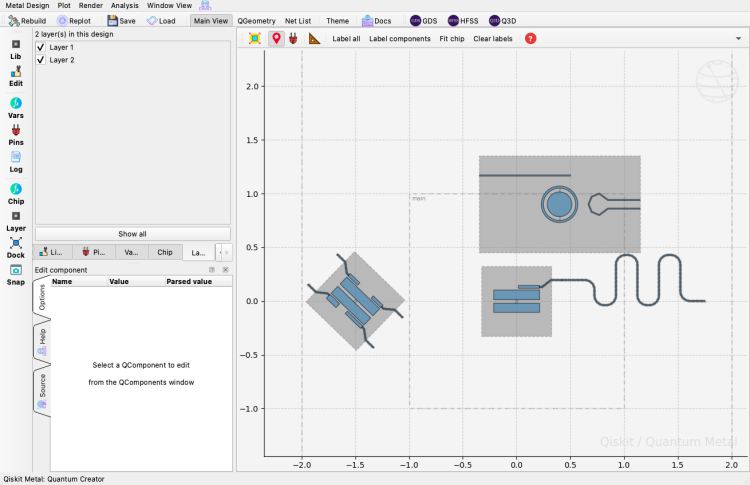

In [8]:
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.mixed_path import RouteMixed
from qiskit_metal.qlibrary.qubits.transmon_concentric import TransmonConcentric

# As precaution, remove any components already previously to design.
multiplanar_design.delete_all_components()


qubit_cpw_otg_layer = 2
qubit_chip_name = "qubit_chip"


q1 = TransmonPocket(
    multiplanar_design,
    "Q1",
    options=dict(
        pad_width="425 um",
        pocket_height="650um",
        layer=qubit_cpw_otg_layer,
        chip=qubit_chip_name,
        # orientation='44',
        orientation="0",
        connection_pads=dict(readout=dict(loc_W=+1, loc_H=+1, pad_width="200um")),
    ),
)

otg = OpenToGround(
    multiplanar_design,
    "open_to_ground",
    options=dict(
        pos_x="1.75mm",
        pos_y="0um",
        orientation="0",
        layer=qubit_cpw_otg_layer,
        chip=qubit_chip_name,
    ),
)

route_meaander = RouteMeander(
    multiplanar_design,
    "readout",
    Dict(
        layer=qubit_cpw_otg_layer,
        chip=qubit_chip_name,
        total_length="3 mm",
        hfss_wire_bonds=True,
        fillet="90 um",
        lead=dict(start_straight="100um"),
        pin_inputs=Dict(
            start_pin=Dict(component="Q1", pin="readout"),
            end_pin=Dict(component="open_to_ground", pin="open"),
        ),
    ),
)

##############################################################################
optionsQ = dict(
    pad_width="425 um",
    pocket_height="650um",
    layer=qubit_cpw_otg_layer,
    chip=qubit_chip_name,
    orientation="-44",
    # orientation='0',
    connection_pads=dict(  # Qbits defined to have 4 pins
        a=dict(loc_W=+1, loc_H=+1),
        b=dict(loc_W=-1, loc_H=+1, pad_height="30um"),
        c=dict(loc_W=+1, loc_H=-1, pad_width="200um"),
        d=dict(loc_W=-1, loc_H=-1, pad_height="50um"),
    ),
)

q2 = TransmonPocket(
    multiplanar_design, "Q2", options=dict(pos_x="-1.5mm", pos_y="+0.0mm", **optionsQ)
)

##############################################################################
concentric_options = dict(
    # chip='main',
    pos_x="400um",
    pos_y="900um",
    # layer='1',  # default is 1, this is just for example. This component does NOT have option for layer.
    pocket_w="1500um",  # transmon pocket width
    pocket_h="900um",  # transmon pocket height
)

# Create a new Concentric Transmon object with name 'Q1'
qc1 = TransmonConcentric(multiplanar_design, "cc_qubit", options=concentric_options)


gui.rebuild()
gui.autoscale()
gui.screenshot()

## Start the Q3D renderer for Ansys by passing arguments to QQ3DPyaedt.
## The default will use default names for Ansys ProjectName and Ansys DesignName.

In [9]:
multi_q3d = QQ3DPyaedt(multiplanar_design)

# Example of passing names for project and design.
# multi_q3d_1 = QQ3DPyaedt(multiplanar_design, "q3d_project_1", "q3d_design_1")

In [10]:
"""Create a solution setup in Ansys Q3D. If user does not provide
        arguments, they will be obtained from QQ3DPyaedt.default_setup dict.

Args:
    name (str, optional): Name of solution setup. Defaults to None.
    AdaptiveFreq (float, optional): Adaptive frequency in GHz. Defaults to None.
    SaveFields (bool, optional): Whether or not to save fields. Defaults to None.
    Enabled (bool, optional): Whether or not setup is enabled. Defaults to None.
    MaxPass (int, optional): Maximum number of passes. Defaults to None.
    MinPass (int, optional): Minimum number of passes. Defaults to None.
    MinConvPass (int, optional): Minimum number of converged passes. Defaults to None.
    PerError (float, optional): Error tolerance as a percentage. Defaults to None.
    PerRefine (int, optional): Refinement as a percentage. Defaults to None.
    AutoIncreaseSolutionOrder (bool, optional): Whether or not to increase solution order automatically. Defaults to None.
    SolutionOrder (str, optional): Solution order. Defaults to None.
    Solver_Type (str, optional): Solver type. Defaults to None.
"""

QQ3DPyaedt.default_setup

{'name': 'QQ3DPyaedt_setup',
 'AdaptiveFreq': '5.0',
 'SaveFields': 'False',
 'Enabled': 'True',
 'MaxPass': '15',
 'MinPass': '2',
 'MinConvPass': '2',
 'PerError': '0.5',
 'PerRefine': '30',
 'AutoIncreaseSolutionOrder': 'True',
 'SolutionOrder': 'High',
 'Solver_Type': 'Iterative'}

In [ ]:
# Use all default values.
multi_q3d.add_q3d_setup()

# Reduce MaxPass when running notebook as an example.
multi_q3d.add_q3d_setup(name="fun_test", MaxPass=3)

## Render the multi-planar design using the similar convention as planar-design to identify ports.

In [ ]:
multi_q3d.render_design(
    selection=["Q1"], box_plus_buffer=True, open_pins=[("Q1", "readout")]
)


############# Below are samples of different rendering arguments.

# multi_q3d.render_design(selection=['Q1', 'Q2', 'cc_qubit'],
#                        box_plus_buffer=True,
#                        open_pins=[('Q1', 'readout'), ('Q2', 'a'), ('Q2', 'b'),
#                        ('Q2', 'd')])


# multi_q3d.render_design(selection=['mult_planar_readout'])

# multi_q3d.render_design(selection=['readout'])

# multi_q3d.render_design(selection=[], box_plus_buffer=False)

# multi_q3d.render_design(selection=['Q1', 'readout'], box_plus_buffer=True)

# multi_q3d.render_design(selection=[], box_plus_buffer=False)

## Select the name to analyze.  Presently, we have two to choose from.  The default=='QQ3DPyaedt_setup' and 'fun_test'.

In [ ]:
multi_q3d.analyze_setup("fun_test")

## Get the result of analyze_setup.
### You can get the capacitance matrix in pandas dataframes format, for the AdaptiveFreq in GHz which was 5.0 in our example.

In [ ]:
cap_data = multi_q3d.get_capacitance_all_passes("fun_test")

In [ ]:
# For Freq==5.0
all_cap_data = cap_data[5.0]
all_cap_data

In [ ]:
# For 1st pass
pass_1 = cap_data[5.0][1]
pass_1

In [ ]:
# For 2nd pass
pass_2 = cap_data[5.0][2]
pass_2

In [ ]:
# For 3rd pass
pass_3 = cap_data[5.0][3]
pass_3

In [11]:
# 4th pass does not exist, since we limited passes to three passes.
# pass_4 = cap_data[5.0][4]
# pass_4

In [ ]:
# Will disconnect Metal from Ansys, and leave Ansys open.
# multi_q3d.close()

# # If the python script closes, the OS will most likely close Ansys.

# Will close Ansys.
# multi_q3d.force_exit_ansys()